In [2]:
import sys
import os
import numpy as np 
import pandas as pd
import numpy.matlib


import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp

from scipy.optimize import minimize
from scipy.optimize import Bounds
from scipy.optimize import LinearConstraint

import torch
import time
import cvxpy as cp
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle

### Generate data points $X$

In [3]:
# Set the random seed for reproducibility
np.random.seed(42)

# Function to generate clustered data
def generate_clusters(total_points, cluster_percentages):
    """
    Generate clustered data based on specified percentages for each cluster.

    :param total_points: Total number of data points to generate.
    :param cluster_percentages: List of percentages for each cluster (should sum to 1).
    :return: Array of generated points.
    """
    # Validate that percentages sum to 1
    if not np.isclose(sum(cluster_percentages), 1.0):
        raise ValueError("Cluster percentages must sum to 1.")

    # Define the cluster centers
    cluster_centers = [(1, 1), (5, 5), (9, 1), (7, 3), (3, 3), (5, 1)]
    
    # Variance of clusters
    cluster_variance = [0.2, 0.2, 0.3, 0.2, 0.2, 0.1]
    
    if len(cluster_percentages) != len(cluster_centers):
        raise ValueError("The number of cluster percentages must match the number of cluster centers.")
    
    # Initialize an empty array for all points
    X = np.empty((0, 2), dtype=float)

    # Generate points for each cluster based on percentages
    for center, variance, percentage in zip(cluster_centers, cluster_variance, cluster_percentages):
        points_per_cluster = int(total_points * percentage)
        # Generate points from a multivariate normal distribution
        points = np.random.multivariate_normal(mean=center, cov=[[variance, 0], [0, variance]], size=points_per_cluster)
        X = np.vstack((X, points))
    
    return X

# Specify the total number of data points
total_points = 600

# Specify the percentages for each cluster (must sum to 1)
cluster_percentages = [0.1, 0.3, 0.2, 0.2, 0.1, 0.1]

# Generate the data
X_init = generate_clusters(total_points, cluster_percentages)

### Regular Clustering

In [4]:
m = 6
N = total_points
Y = np.mean(X_init,axis = 0)*np.ones((m,2))

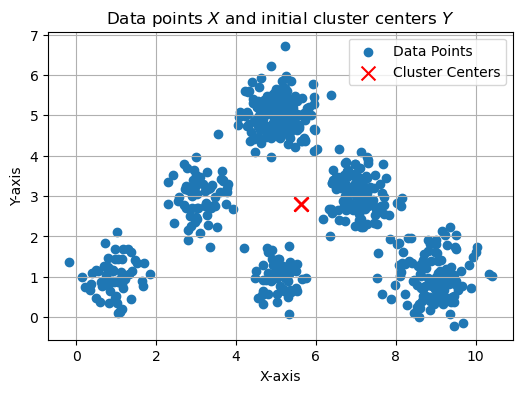

In [9]:
plt.figure(figsize=(6, 4))  # Set the size of the plot
plt.scatter(X_init[:, 0], X_init[:, 1], label='Data Points')
plt.scatter(Y[:, 0], Y[:, 1], color='red', marker='x', s=100, label='Cluster Centers')  # Plot cluster centers
plt.title("Data points $X$ and initial cluster centers $Y$")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.show() 

In [6]:
def cluster_beta(X_init,Y_init,m,beta,pert):
    N = np.shape(X_init)[0]
    Y_init += pert * (np.arange(m)+1).reshape(-1,1) * np.ones((m,2))
    X_expanded = np.expand_dims(X_init, 1)  # Shape (N, 1, 2)
    Y_expanded = np.expand_dims(Y_init, 0)       # Shape (1, m, 2)

    # Compute the squared differences, sum over the coordinate axis (axis=2)
    distances = np.sum((X_expanded - Y_expanded) ** 2, axis=2)
    distances_n = distances - np.min(distances, axis = 1).reshape(-1,1)
    P_yx = np.exp(-beta * distances_n)/(np.sum(np.exp(-beta * distances_n),axis = 1).reshape(-1,1))
    P_xy = P_yx/(np.sum(P_yx, axis = 0).reshape(1,-1))
    Y_c = P_xy.T @ X_init
    return Y_c, P_yx, P_xy

In [7]:
def clustering(X_init,m,pert,beta_final,alpha):
    beta = 0.01
    Y_init = np.mean(X_init,axis = 0)*np.ones((m,2))
    while beta <= beta_final:
        Y, P_yx, P_xy = cluster_beta(X_init,Y_init,m,beta,pert)
        beta *= alpha 
        Y_init = Y
        
    return Y, P_yx

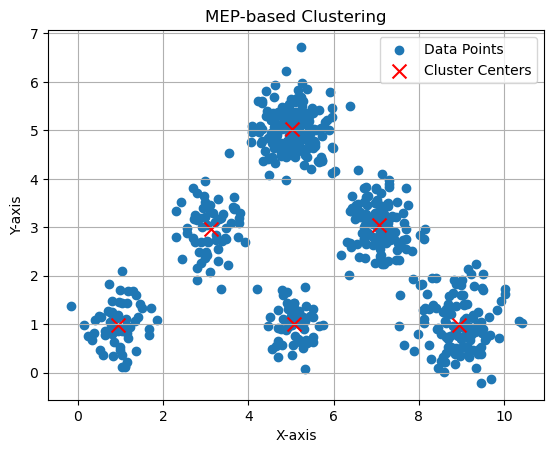

In [8]:
pert = 10e-10
m = 6
beta_final = 5
alpha = 1.05
Y_c, P_yx_c = clustering(X_init,m,pert,beta_final,alpha)
plt.scatter(X_init[:,0], X_init[:,1], label='Data Points')
plt.scatter(Y_c[:, 0], Y_c[:, 1], color='red', marker='x', s=100, label='Cluster Centers')  # Plot cluster centers
plt.title(f"MEP-based Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.show()

## Free energy funcvtion and its time derivative

In [10]:
def Gibbs_distribution(X, Y, beta):
    N = X.shape[0]
    m = Y.shape[0]
    X_expanded = np.expand_dims(X, 1)       # Shape (N, 1, 2)
    Y_expanded = np.expand_dims(Y, 0)       # Shape (1, m, 2)
    distances = np.sum((X_expanded - Y_expanded) ** 2, axis=2)
    distances_n = distances - np.min(distances, axis = 1).reshape(-1,1)
    P_ylx_G = np.exp(-beta * distances_n)/(np.sum(np.exp(-beta * distances_n),axis = 1).reshape(-1,1))

    return P_ylx_G

In [11]:
def Free_Energy(X, Y, q, P_ylx, beta):
    # Computation of the free energy
    N = X.shape[0]
    m = Y.shape[0]
    X_expanded = np.expand_dims(X, 1)       # Shape (N, 1, 2)
    Y_expanded = np.expand_dims(Y, 0)       # Shape (1, m, 2)
    distances = np.sum((X_expanded - Y_expanded) ** 2, axis=2)
    Px = np.diag(q)
    Py = np.sum(Px @ P_ylx, axis = 0)
    F = np.sum(Px @ np.multiply(P_ylx, distances + 1/beta * np.log(P_ylx)))

    return F

In [12]:
def Free_Energy_ver2(X, Y, q, beta):
    # Computation of the free energy
    N = X.shape[0]
    m = Y.shape[0]
    X_expanded = np.expand_dims(X, 1)       # Shape (N, 1, 2)
    Y_expanded = np.expand_dims(Y, 0)       # Shape (1, m, 2)
    distances = np.sum((X_expanded - Y_expanded) ** 2, axis=2)
    distances_n = distances - np.min(distances, axis = 1).reshape(-1,1)
    Px = np.diag(q)
    P_ylx_G = np.exp(-beta * distances_n)/(np.sum(np.exp(-beta * distances_n),axis = 1).reshape(-1,1))
    Py = np.sum(Px @ P_ylx_G, axis = 0)
    F = np.sum(Px @ np.multiply(P_ylx_G, distances + 1/beta * np.log(P_ylx_G)))

    return F

In [13]:
def F_Fdot_clustering(X, Y, q, P_ylx, u_y, u_p, u_b, beta):
    # Computation of the free energy
    N = X.shape[0]
    m = Y.shape[0]
    X_expanded = np.expand_dims(X, 1)       # Shape (N, 1, 2)
    Y_expanded = np.expand_dims(Y, 0)       # Shape (1, m, 2)
    distances = np.sum((X_expanded - Y_expanded) ** 2, axis=2)
    Px = np.diag(q)
    Py = np.sum(Px @ P_ylx, axis = 0)
    F = np.sum(Px @ np.multiply(P_ylx, distances + 1/beta * np.log(P_ylx)))
    F_shifted = F + 1/beta * np.log(m)

    # Time derivatives
    ## w.r.t Y: sum_{j=1}^m (dF/dy_j)^T u_j
    dFdY = 2 * (Py[:, np.newaxis] * Y - P_ylx.T @ Px @ X_init)
    dotF_y = cp.sum(cp.multiply(dFdY,u_y))

    ## w.r.t P_{y|x}: \sum_{i,j} dF/dp_{j|i} v_ij
    dotF_p = cp.sum(cp.multiply(Px @ (distances + 1/beta * np.log(P_ylx) + 1/beta), u_p))

    ## w.r.t beta: (1/beta)^2 H
    dFdb = -1/beta**2 * np.sum(Px @ np.multiply(P_ylx, np.log(P_ylx)))
    dotF_beta = dFdb * u_b

    # Total time derivative
    Fdot = dotF_y + dotF_p + dotF_beta

    return F_shifted, Fdot

In [14]:
def F_Fdot_clustering_ver2(X, Y, q, u_y, u_b, beta):
    # Computation of the free energy
    N = X.shape[0]
    m = Y.shape[0]
    X_expanded = np.expand_dims(X, 1)       # Shape (N, 1, 2)
    Y_expanded = np.expand_dims(Y, 0)       # Shape (1, m, 2)
    distances = np.sum((X_expanded - Y_expanded) ** 2, axis=2)
    distances_n = distances - np.min(distances, axis = 1).reshape(-1,1)
    Px = np.diag(q)
    P_ylx_G = np.exp(-beta * distances_n)/(np.sum(np.exp(-beta * distances_n),axis = 1).reshape(-1,1))
    Py = np.sum(Px @ P_ylx_G, axis = 0)
    F = np.sum(Px @ np.multiply(P_ylx_G, distances + 1/beta * np.log(P_ylx_G)))
    F_shifted = F + 1/beta * np.log(m)

    # Time derivatives
    ## w.r.t Y: sum_{j=1}^m (dF/dy_j)^T u_j
    dFdY = 2 * (Py[:, np.newaxis] * Y - P_ylx_G.T @ Px @ X_init)
    dotF_y = cp.sum(cp.multiply(dFdY,u_y))

    ## w.r.t beta: (1/beta)^2 H
    dFdb = -1/beta**2 * np.sum(Px @ np.multiply(P_ylx_G, np.log(P_ylx_G)))
    dotF_beta = dFdb * u_b

    # Total time derivative
    Fdot = dotF_y + dotF_beta

    return F_shifted, Fdot

### Control barrier functions

In [15]:
def h_hdot(P_ylx, u_p):
    h = P_ylx * (1 - P_ylx)
    hdot = cp.multiply((1 - 2 * P_ylx), u_p)
    return h, hdot

In [16]:
def l_ldot(c, q, P_ylx, u_p):
    l = c - np.dot(q, P_ylx)
    ldot = - (q[:,np.newaxis].T @ u_p).flatten()
    return l, ldot

### Controllers

In [17]:
def control_dyn(X, Y, q, P_ylx, beta, u_b, p, gamma, alpha_h, alpha_l, c):
    # Decision variables 
    u_p = cp.Variable((N,m))
    u_y = cp.Variable((m,2))  
    # u_y = cp.Parameter((m,2))
    # u_y.value = np.zeros((m,2))
    delta = cp.Variable(1)

    ## Constant parameters of the QP
    # p = 1000
    # gamma = 1
    # alpha_h = 10
    # alpha_l = 10

    # Objective: minimize the sum of squares of x and the sum of q
    objective = cp.Minimize(cp.sum_squares(u_p) + cp.sum_squares(u_y) + p * delta**2)

    # Define constraints
    F , Fdot = F_Fdot_clustering(X, Y, q, P_ylx, u_y, u_p, u_b, beta)
    h, h_dot = h_hdot(P_ylx, u_p)
    l, l_dot = l_ldot(c, q, P_ylx, u_p)

    constraints = [
        Fdot <= -gamma * F + delta,
        cp.sum(u_p, axis=1) == 0,
        h_dot >= -alpha_h * h,
        l_dot >= -alpha_l * l
    ]

    # Define the problem
    problem = cp.Problem(objective, constraints)

    # Solver Options for OSQP
    solver_options = {
        'max_iter': 50000,         # Increase max iterations to 20000
        'eps_abs': 1e-4,           # Adjust absolute tolerance
        'eps_rel': 1e-4,           # Adjust relative tolerance
        'eps_prim_inf': 1e-3,      # Adjust primal infeasibility tolerance
        'eps_dual_inf': 1e-3,      # Adjust dual infeasibility tolerance
        'verbose': False           # Enable verbose output to track solver progress
    }

    # Solve the problem using OSQP with customized options
    result = problem.solve(solver = 'OSQP', **solver_options)
    
    # Check the results
    if np.isnan(problem.value).any() == True:
        print("Nan encountered!")
        return np.zeros((N,m)), np.zeros((m,2)), F, 0
    else:         
        return u_p.value, u_y.value, F, Fdot.value

In [18]:
# This version is for debugging and includes constraint values 
def control_dyn_debug(X, Y, q, P_ylx, beta, u_b, p, gamma, alpha_h, alpha_l):
    # Decision variables 
    u_p = cp.Variable((N,m))
    # u_y = cp.Variable((m,2))  
    u_y = cp.Parameter((m,2))
    u_y.value = np.zeros((m,2))
    delta = cp.Variable(1)

    ## Constant parameters of the QP
    # p = 1000
    # gamma = 1
    # alpha_h = 10
    #alpha_l = 10

    # Objective: minimize the sum of squares of x and the sum of q
    objective = cp.Minimize(cp.sum_squares(u_p) + cp.sum_squares(u_y) + p * delta**2)

    # Define constraints
    F , Fdot = F_Fdot_clustering(X, Y, q, P_ylx, u_y, u_p, u_b, beta)
    h, h_dot = h_hdot(P_ylx, u_p)
    l, l_dot = l_ldot(c, q, P_ylx, u_p)

    constraints = [
        Fdot <= -gamma * F + delta,
        cp.sum(u_p, axis=1) == 0,
        h_dot >= -alpha_h * h,
        l_dot >= -alpha_l * l
    ]

    # Define the problem
    problem = cp.Problem(objective, constraints)

    # Solver Options for OSQP
    solver_options = {
        'max_iter': 50000,         # Increase max iterations to 20000
        'eps_abs': 1e-4,           # Adjust absolute tolerance
        'eps_rel': 1e-4,           # Adjust relative tolerance
        'eps_prim_inf': 1e-3,      # Adjust primal infeasibility tolerance
        'eps_dual_inf': 1e-3,      # Adjust dual infeasibility tolerance
        'verbose': True            # Enable verbose output to track solver progress
    }

    # Solve the problem using OSQP with customized options
    result = problem.solve(solver = 'OSQP', **solver_options)

    
    # Check the results
    if np.isnan(problem.value).any() == True:
        print("Nan encountered!")
        return np.zeros((N,m)), np.zeros((m,2))
    else:         
        return u_p.value, u_y.value, F, Fdot.value, h, h_dot.value, l, l_dot.value, delta.value

In [19]:
# Auxiliary functions to project back into the feasible space
def project_to_stochastic_matrix(matrix):
    """
    Projects each row of the input matrix onto the simplex (triangle) defined by:
    - The row sums to 1
    - Each element in the row lies within [0, 1]

    :param matrix: np.ndarray, the input matrix (shape: NxM)
    :return: np.ndarray, the projected matrix (same shape as input)
    """
    def project_to_plane(vector):
        N = vector.shape[0]
        normal = np.ones((N,))
        p = 1 / N * np.ones((N,))
        n_dot_n = N
        v_dot_n = np.dot(vector, normal)
        p_dot_n = np.dot(p, normal)
        projection = vector - ((v_dot_n - p_dot_n) / n_dot_n) * normal
        return projection

    def project_to_triangle(v):
        tol = 1e-7
        v_proj = project_to_plane(v)
        v_clamped = np.clip(v_proj, tol, 1 - tol)
        sum_clamped = np.sum(v_clamped)

        if sum_clamped == 1:
            return v_clamped
        elif sum_clamped < 1:
            deficit = 1 - sum_clamped
            free_indices = v_clamped < 1
            num_free = np.sum(free_indices)
            if num_free > 0:
                increment = deficit / num_free
                v_clamped[free_indices] += increment
            return v_clamped
        else:
            return v_clamped / sum_clamped

    # Apply the projection to each row of the matrix
    projected_matrix = np.apply_along_axis(project_to_triangle, axis=1, arr=matrix)
    return projected_matrix

### Numerical simulation

In [20]:
def dynamics_v2(z, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m):
    """
    Computes the time derivative of the state.
    
    Parameters:
      t       : time (not used explicitly here, but required by solve_ivp)
      z       : flattened state vector [Y.flatten(), P.flatten(), beta]
      X_init  : initial parameter or state used in control_dyn
      q, u_b, p, gamma, alpha_h, alpha_l : additional parameters for control_dyn
      N       : mumber of data poits
      m       : number of facilities
      
    Returns:
      dz/dt  : flattened derivative vector.
    """
    # Unpack the state vector
    n_Y = m * 2
    n_P = N * m
    Y = z[0:n_Y].reshape(m,2)
    P = z[n_Y:n_Y+n_P].reshape(N,m)
    u_b = 0
    

    # Compute control inputs; control_dyn should return u_p and u_y for state evolution.
    u_p, u_y, F_b, Fdot_b = control_dyn(X_init, Y, q, P, beta, u_b, p, gamma, alpha_h, alpha_l, c)
    
    # Compute the derivatives
    dY_dt = u_y           # dY/dt = u_y
    dP_dt = u_p           # dP/dt = u_p
    
    # Flatten the derivatives into a single vector
    dzdt = np.concatenate([dY_dt.flatten(), dP_dt.flatten()])
    return dzdt, F_b, Fdot_b

In [21]:
def euler_forward_stat(dynamics, z0, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m, T_f, dt, tol=1e-2):
    """
    Forward Euler integration with projection step for P.
    Breaks loop early if abs(Fdot) falls below tol.

    Parameters:
      dynamics : function returning dz/dt
      z0       : initial state
      T_f      : final time
      dt       : time step
      tol      : stopping criterion for abs(Fdot)
      
    Returns:
      dz/dt    : flattened derivative vector.
    """
    num_steps = int(T_f / dt)
    times = np.zeros(num_steps + 1)
    # F_ar = np.zeros(num_steps)
    # Fdot_ar = np.zeros(num_steps)

    t = 0.0
    z = z0

    for i in range(num_steps):

        # Compute time derivative
        dzdt, F, Fdot = dynamics(z, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m)

        # Break loop if |Fdot| is too small
        if abs(Fdot) < tol:
            print(f"Terminating early at step {i}, time {times[i]} because abs(Fdot)={abs(Fdot):.6f} < tol={tol}")
            # return times[:i+1], traj[:i+1], F_ar[:i], Fdot_ar[:i]  # Return only computed values
            return z + dzdt * dt                           # Return only computed values

        # Euler update
        z_next = z + dt * dzdt

        # Projection step for P
        n_Y = m * 2
        n_P = N * m
        Y_next = z_next[:n_Y].reshape(m, 2)
        P_next = z_next[n_Y:].reshape(N, m)

        # Apply projection to P
        P_projected = project_to_stochastic_matrix(P_next)

        # Reassemble state with projected P
        z_projected = np.concatenate([Y_next.flatten(), P_projected.flatten()])
        z = z_projected

        # Store projected state
        times[i+1] = times[i] + dt  # Store time
        # F_ar[i] = F
        # Fdot_ar[i] = Fdot

    # return times, traj, F_ar, Fdot_ar
    return z

In [22]:
def adaptive_euler_forward(dynamics, z0, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m, T_f, dt_init=0.01, dt_min=1e-4, dt_max=0.1, tol=1e-2):
    """
    Adaptive Euler integration with projection step for P based on Adaptive Gradient Descent.
    Includes modifications to prevent step size shrinking.

    Parameters:
      dynamics : function returning dz/dt
      z0       : initial state
      T_f      : final time
      dt_init  : initial step size (lambda_0 in algorithm)
      dt_min   : minimum allowable step size
      dt_max   : maximum allowable step size
      tol      : stopping criterion for abs(Fdot)
      
    Returns:
      z : final state after integration
    """
    
    # Initialization
    z_prev = z0
    dt_prev = dt_init  # lambda_0
    theta_prev = np.inf  # theta_0 = +inf
    t = 0.0
    iter_count = 0

    while t < T_f:
        # Compute gradient step
        dzdt, F, Fdot = dynamics(z_prev, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m)

        # Termination condition if |Fdot| is too small
        if abs(Fdot) < tol:
            print(f"Terminating early at iteration {iter_count}, time {t} because abs(Fdot)={abs(Fdot):.6f} < tol={tol}")
            break

        # Compute new step size (lambda_k)
        if iter_count > 0:
            step_size_1 = np.sqrt(1 + theta_prev) * dt_prev
            grad_diff = np.linalg.norm(dzdt - dzdt_old) + 1e-6  # Regularization term to prevent division by zero
            step_size_2 = np.linalg.norm(z_prev - z_old) / (2 * grad_diff)  

            dt = min(max(step_size_1, dt_min), dt_max)  # Keep dt in range [dt_min, dt_max]
        else:
            dt = dt_init  # First iteration uses initial step size

        # Euler update
        z_next = z_prev + dt * dzdt

        # Projection step for P
        n_Y = m * 2
        n_P = N * m
        Y_next = z_next[:n_Y].reshape(m, 2)
        P_next = z_next[n_Y:].reshape(N, m)

        # Apply projection to P
        P_projected = project_to_stochastic_matrix(P_next)

        # Reassemble state with projected P
        z_projected = np.concatenate([Y_next.flatten(), P_projected.flatten()])

        # Compute new theta_k
        if iter_count > 0:
            theta = dt / dt_prev
        else:
            theta = 1.0  # Initial theta value

        # Update variables for next iteration
        z_old = z_prev
        dzdt_old = dzdt
        dt_prev = dt
        theta_prev = theta
        z_prev = z_projected
        t += dt
        iter_count += 1

    return z_prev

In [24]:
# Initialize z0
# Initialization Y and P
Y0 = np.mean(X_init,axis = 0)*np.ones((m,2))
Y0 = Y0 + pert * np.random.rand(m,2)
# Y0 = 10 * np.random.rand(m,2)
# Y0 = np.ones((m,2))

P0 = np.random.rand(N, m)
P0 = P0 / P0.sum(axis=1, keepdims=True)
# P0 = 1/m * np.ones((N,m))

q = 1/N * np.ones(N)
Px = np.diag(q)
pert = 1e-6

Py = np.sum(Px @ P0, axis = 0)
c = 1 * np.ones(m) + pert

z0_init = np.concatenate([Y0.flatten(), P0.flatten()])
z0 = np.copy(z0_init)  # Ensure z0 is not modified in-place

# Setting the coefficients
alpha_h = 20
alpha_l = 20
p = 1000
gamma = 1

# Determine the size of z for array storage
z_dim = z0.shape[0]  # Get the dimension of z0

# Initialize beta
beta_init = 0.1  # Starting value of beta
beta_factor = 1.5  # Geometric growth factor for beta
beta_final = 20  # Final beta value for stopping condition

# Estimate the maximum number of iterations needed (including initialization)
max_iterations = int(np.ceil(np.log(beta_final / beta_init) / np.log(beta_factor))) + 1

# Preallocate storage arrays
z_values = np.zeros((max_iterations, z_dim))  # Store all z values
beta_values = np.zeros(max_iterations)        # Store beta values

# Store the initial values
z_values[0, :] = z0_init
beta_values[0] = beta_init

# Loop over increasing beta values
beta = beta_init
counter = 1  # Start from 1 since initialization is already stored
c = 1 * np.ones(m)

while beta < beta_final:
    print(f"Iteration {counter}: Solving for beta = {beta}")

    # Solve with the current beta
    # z = adaptive_euler_forward_stat(dynamics_v2, z0, X_init, beta, q, p, gamma, alpha_h, alpha_l, N, m, T_f, dt_init = 0.005, tol=0.1, min_dt=1e-3, max_dt=0.5)
    # z = euler_forward_stat(dynamics_v2, z0, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m, T_f=2, dt=0.01, tol=1e-2)
    z = adaptive_euler_forward(dynamics_v2, z0, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m, T_f=15, dt_init=0.01, dt_min=1e-4, dt_max=0.1, tol=1e-2)
    # z = adaptive_accelerated_gd(dynamics_v2, z0, X_init, beta, q, p, gamma, alpha_h, alpha_l, c, N, m, T_f = 10, dt_init=0.01, dt_min=1e-4, dt_max=0.1, tol=1e-2, beta_clip=0.5, max_iters=1000)
    
    # Store results
    beta_values[counter] = beta
    z_values[counter, :] = z  # Store z in preallocated array

    # Increase beta geometrically
    beta *= beta_factor  # Geometric increase

    # Optionally update z0 for the next iteration
    z0 = np.copy(z)  # Continue from the previous result

    counter += 1  # Update counter

# Trim arrays to actual number of iterations
beta_values = beta_values[:counter]
z_values = z_values[:counter, :]

Iteration 1: Solving for beta = 0.1
Iteration 2: Solving for beta = 0.15000000000000002
Iteration 3: Solving for beta = 0.22500000000000003
Iteration 4: Solving for beta = 0.3375
Iteration 5: Solving for beta = 0.5062500000000001
Iteration 6: Solving for beta = 0.7593750000000001
Iteration 7: Solving for beta = 1.1390625
Iteration 8: Solving for beta = 1.7085937500000001
Iteration 9: Solving for beta = 2.562890625
Iteration 10: Solving for beta = 3.8443359375000004
Iteration 11: Solving for beta = 5.7665039062500005
Terminating early at iteration 111, time 10.729303955709623 because abs(Fdot)=0.005865 < tol=0.01
Iteration 12: Solving for beta = 8.649755859375
Terminating early at iteration 0, time 0.0 because abs(Fdot)=0.004432 < tol=0.01
Iteration 13: Solving for beta = 12.974633789062501
Terminating early at iteration 0, time 0.0 because abs(Fdot)=0.004299 < tol=0.01
Iteration 14: Solving for beta = 19.461950683593752
Terminating early at iteration 0, time 0.0 because abs(Fdot)=0.004

In [25]:
n_Y = m * 2  # Y has shape (m, 2)
n_P = N * m  # P has shape (N, m)

# ind = -3
Y_traj = z_values[:, :n_Y].reshape(-1, m, 2)
P_traj = z_values[:, n_Y:].reshape(-1, N, m)

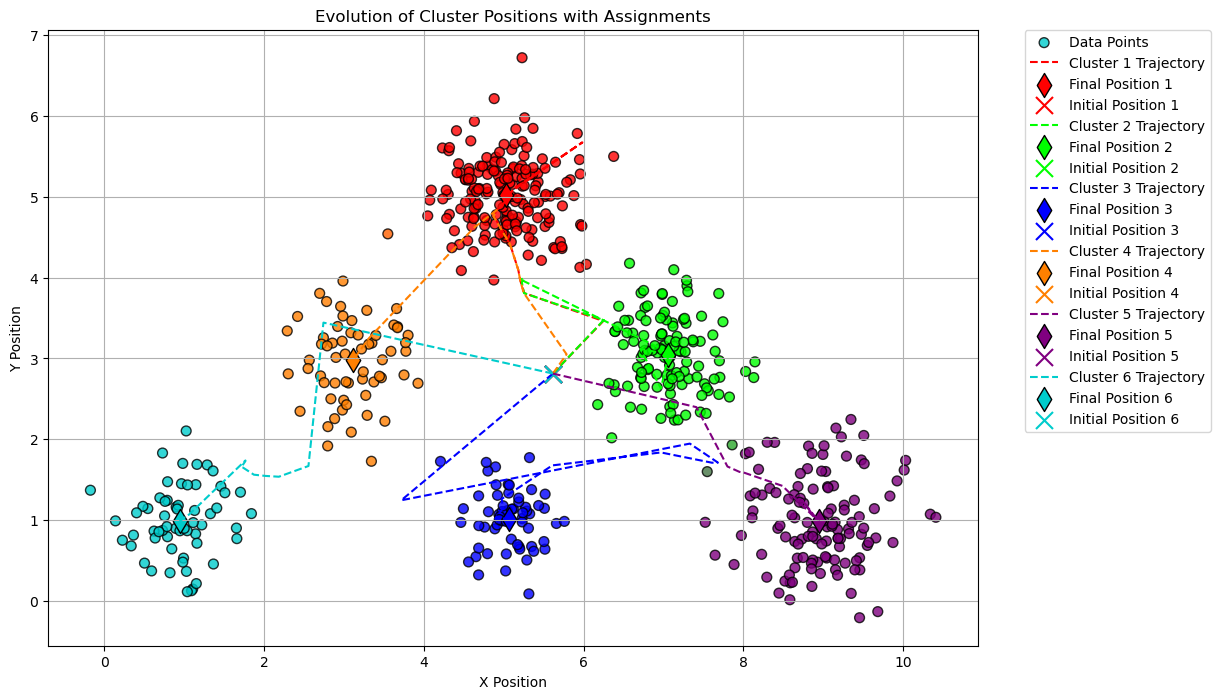

In [26]:
# Define a color for each cluster (RGB values) - Now for 6 clusters
resource_colors = np.array([
    [1, 0, 0],      # Red for cluster 1
    [0, 1, 0],      # Green for cluster 2
    [0, 0, 1],      # Blue for cluster 3
    [1, 0.5, 0],    # Orange for cluster 4
    [0.5, 0, 0.5],  # Purple for cluster 5
    [0, 0.8, 0.8]   # Cyan for cluster 6
])

# Plot setup
plt.figure(figsize=(12, 8))

# Compute colors for each data point at the final time step
data_colors = np.dot(P_traj[-1], resource_colors)  # Weighted sum of cluster colors at final step

# Plot data points with computed colors
plt.scatter(
    X_init[:, 0], X_init[:, 1],
    c=data_colors, s=50, edgecolor='k', alpha=0.8, label="Data Points"
)

# Plot trajectories and final positions of clusters
for i in range(m):
    plt.plot(
        Y_traj[:, i, 0], Y_traj[:, i, 1],  # Extract trajectory over time for cluster i
        label=f"Cluster {i+1} Trajectory", linestyle="--", color=resource_colors[i]
    )

    # Mark final positions of clusters
    plt.scatter(
        Y_traj[-1, i, 0], Y_traj[-1, i, 1],
        marker="d", s=150, color=resource_colors[i], edgecolor='k', alpha=1, label=f"Final Position {i+1}"
    )

    # Mark initial positions of clusters
    plt.scatter(
        Y_traj[0, i, 0], Y_traj[0, i, 1],
        marker="x", s=150, color=resource_colors[i], label=f"Initial Position {i+1}"
    )

# Customize the plot
plt.title("Evolution of Cluster Positions with Assignments")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.show()

In [27]:
print('Final free energy value: ', Free_Energy(X_init, Y_traj[-1,:,:],q, P_traj[-1,:,:], beta_values[-1]))

Final free energy value:  0.4040505350803454


In [28]:
Py = np.sum(Px @ P_traj[-1,:,:], axis = 0)
print(Py)

[0.29861633 0.20199689 0.10001087 0.10126408 0.19811179 0.10000004]


In [29]:
np.min(np.max(P_traj[-1,:,:], axis=1))

0.5374728016547589